# Activations, gradients, and initialization

Part 3 of Karpathy’s *makemore* series keeps the same character-level MLP and asks a more diagnostic question: **what is happening inside the network while it learns?**

The earlier notebooks established the data path and the output loss. Here we inspect the quantities that determine whether gradient descent has a useful signal:

- the loss we should expect before learning;
- the difference between a small, uncertain initialization and a confidently wrong one;
- saturation in `tanh` and the resulting vanishing gradients;
- dead `ReLU` units;
- why weight scale should depend on fan-in;
- what BatchNorm standardizes, and why training and inference use different statistics.

The examples are deliberately small. Their purpose is to make the training mechanics visible, not to claim a language-model benchmark.

## How this fits the first three lectures

The three lectures form one continuous construction:

1. **Part 1 — bigram language modeling:** count character pairs, normalize each row into \(P(c_{t+1}\mid c_t)\), sample, and evaluate with negative log likelihood.
2. **Part 2 — an MLP:** replace the count table with learnable embeddings, a hidden layer, and one output logit per possible next character. Cross-entropy trains the whole parameter set.
3. **Part 3 — training behavior:** inspect logits, activations, and gradients so initialization and optimization are not treated as magic.

The model family has changed, but the target remains the same: assign high probability to the observed next character.

In [1]:
import math

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from torch import nn

sns.set_theme(style="whitegrid", context="notebook")
torch.manual_seed(7)

VOCAB_SIZE = 27


Matplotlib is building the font cache; this may take a moment.


## 1. The loss has a predictable starting point

If there are \(V\) possible next characters and the model begins with a uniform distribution, the correct character receives probability \(1/V\). The expected negative log likelihood is therefore

\[
\mathcal L_0 = -\log(1/V)=\log V.
\]

For the 27-character vocabulary used in `makemore`, this is about 3.30. This is a useful sanity check: a fresh model should not begin with an arbitrary loss such as 20 or 30 merely because its weights were initialized randomly. A large initial loss often means that the output logits are already making very confident predictions before the model has learned anything.

In [2]:
vocab_sizes = torch.tensor([2, 4, 10, 27, 100, 1000], dtype=torch.float32)
expected_loss = torch.log(vocab_sizes)
summary = pd.DataFrame({"vocabulary size": vocab_sizes.long(), "uniform probability": 1 / vocab_sizes, "expected NLL": expected_loss})
summary

,vocabulary size,uniform probability,expected NLL
0,2,0.500000,0.693147
1,4,0.250000,1.386294
2,10,0.100000,2.302585
3,27,0.037037,3.295837
4,100,0.010000,4.605170
5,1000,0.001000,6.907755


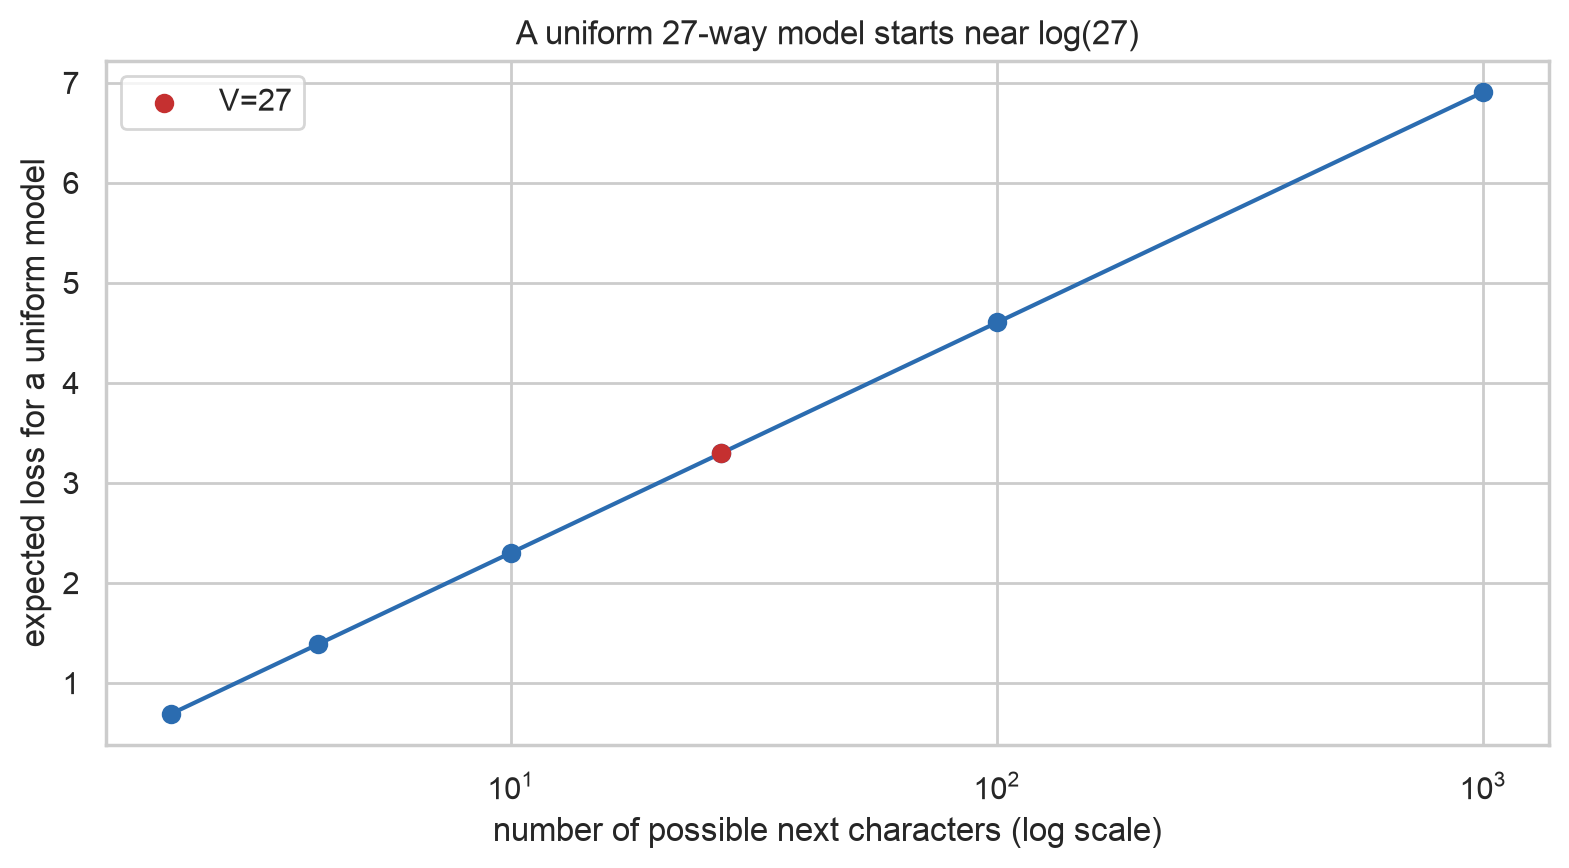

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(vocab_sizes, expected_loss, marker="o", color="#2b6cb0")
ax.scatter([VOCAB_SIZE], [math.log(VOCAB_SIZE)], color="#c53030", zorder=3, label=f"V={VOCAB_SIZE}")
ax.set_xscale("log")
ax.set_xlabel("number of possible next characters (log scale)")
ax.set_ylabel("expected loss for a uniform model")
ax.set_title("A uniform 27-way model starts near log(27)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Small logits and confidently wrong logits

Softmax only cares about relative differences between logits. If all logits are close together, the distribution is close to uniform. If one incorrect logit is much larger than the rest, the model is confidently wrong and the loss becomes large.

This explains the “hockey-stick” beginning of an improperly initialized training curve: the first useful updates may be spent shrinking an accidental confidence scale before the network can learn which character should win.

In [4]:
target = 3
base_logits = torch.zeros(VOCAB_SIZE)
scales = torch.tensor([0.01, 0.1, 1.0, 3.0])
losses = []
correct_probs = []
wrong_probs = []

for scale in scales:
    logits = base_logits.clone()
    logits[0] = 5.0 * scale  # an incorrect class
    logits[target] = 0.0
    probabilities = torch.softmax(logits, dim=0)
    losses.append(torch.nn.functional.cross_entropy(logits.unsqueeze(0), torch.tensor([target])).item())
    correct_probs.append(probabilities[target].item())
    wrong_probs.append(probabilities[0].item())

comparison = pd.DataFrame({
    "logit scale": scales,
    "target probability": correct_probs,
    "incorrect probability": wrong_probs,
    "cross-entropy": losses,
})
comparison

,logit scale,target probability,incorrect probability,cross-entropy
0,0.01,3.696683e-02,0.038862,3.297734
1,0.10,3.616804e-02,0.059631,3.319580
2,1.00,5.733512e-03,0.850929,5.161427
3,3.00,3.058998e-07,0.999992,15.000009


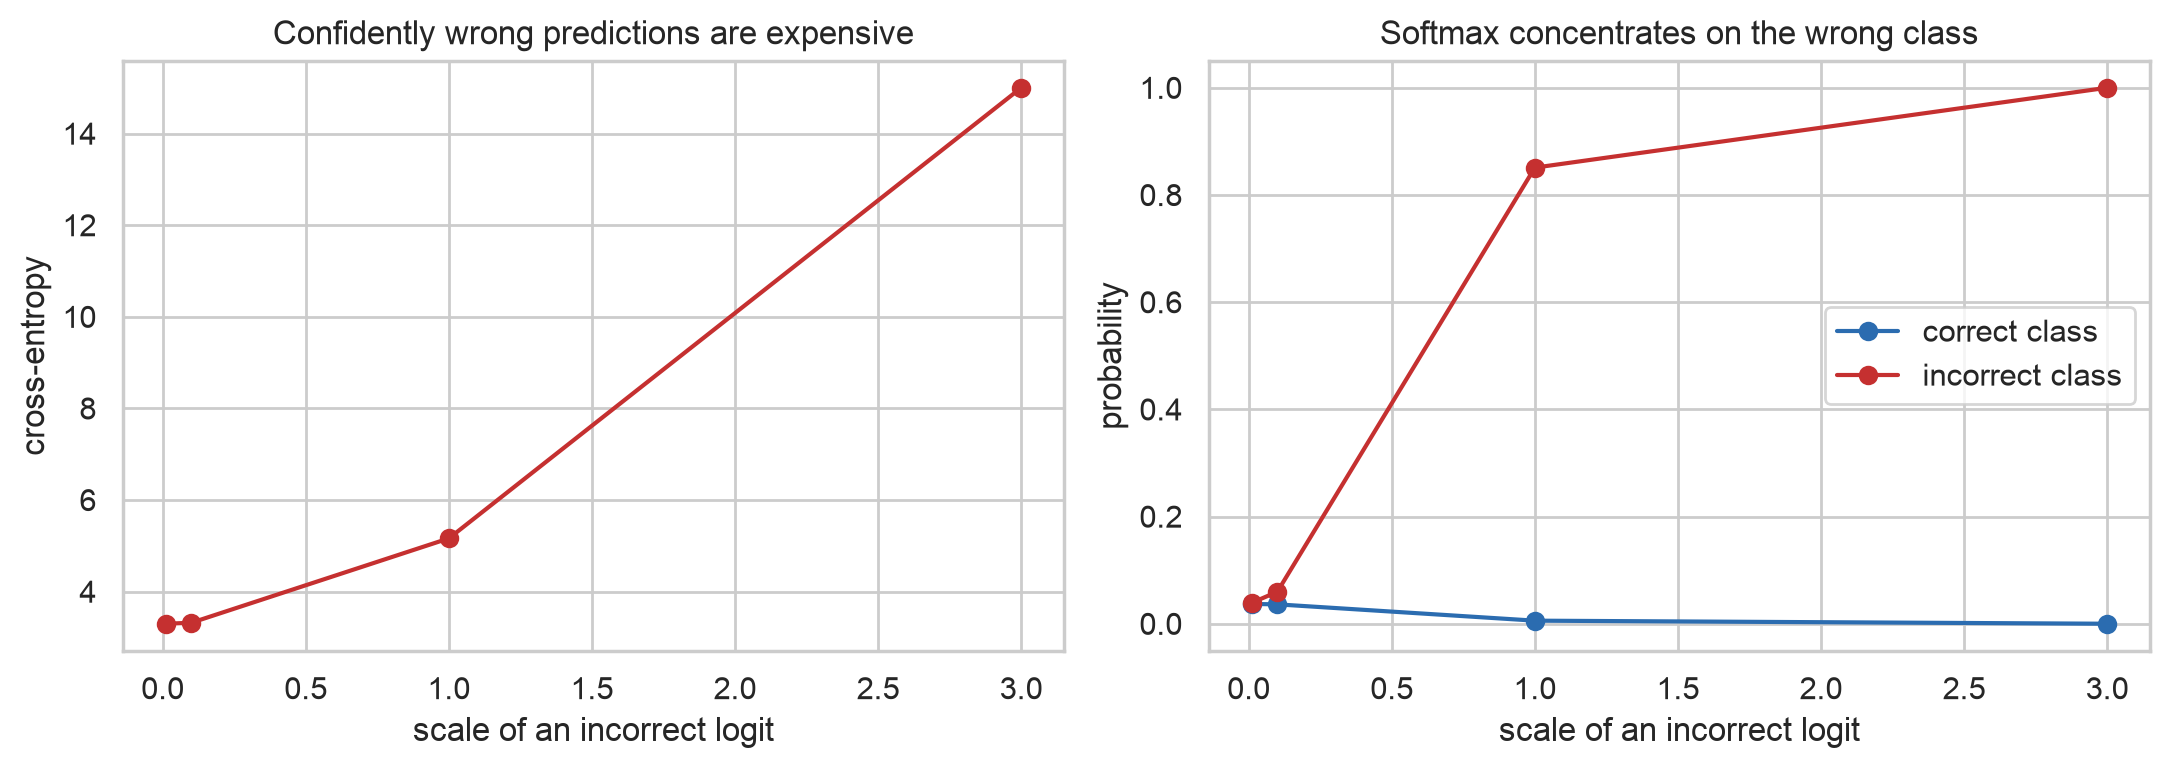

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(scales, losses, marker="o", color="#c53030")
axes[0].set(xlabel="scale of an incorrect logit", ylabel="cross-entropy", title="Confidently wrong predictions are expensive")
axes[1].plot(scales, correct_probs, marker="o", label="correct class", color="#2b6cb0")
axes[1].plot(scales, wrong_probs, marker="o", label="incorrect class", color="#c53030")
axes[1].set(xlabel="scale of an incorrect logit", ylabel="probability", title="Softmax concentrates on the wrong class")
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. Saturation controls the gradient

A nonlinear activation is useful because it lets stacked layers represent functions that a single linear transformation cannot. But its derivative determines whether a learning signal can pass through it.

For `tanh`,

\[
rac{d}{dx}	anh(x)=1-	anh^2(x).
\]

Near zero, the derivative is close to one. In the flat tails, the derivative is close to zero. A hidden unit whose pre-activation is mostly in those tails still produces a number, but its gradient is almost erased during backpropagation.

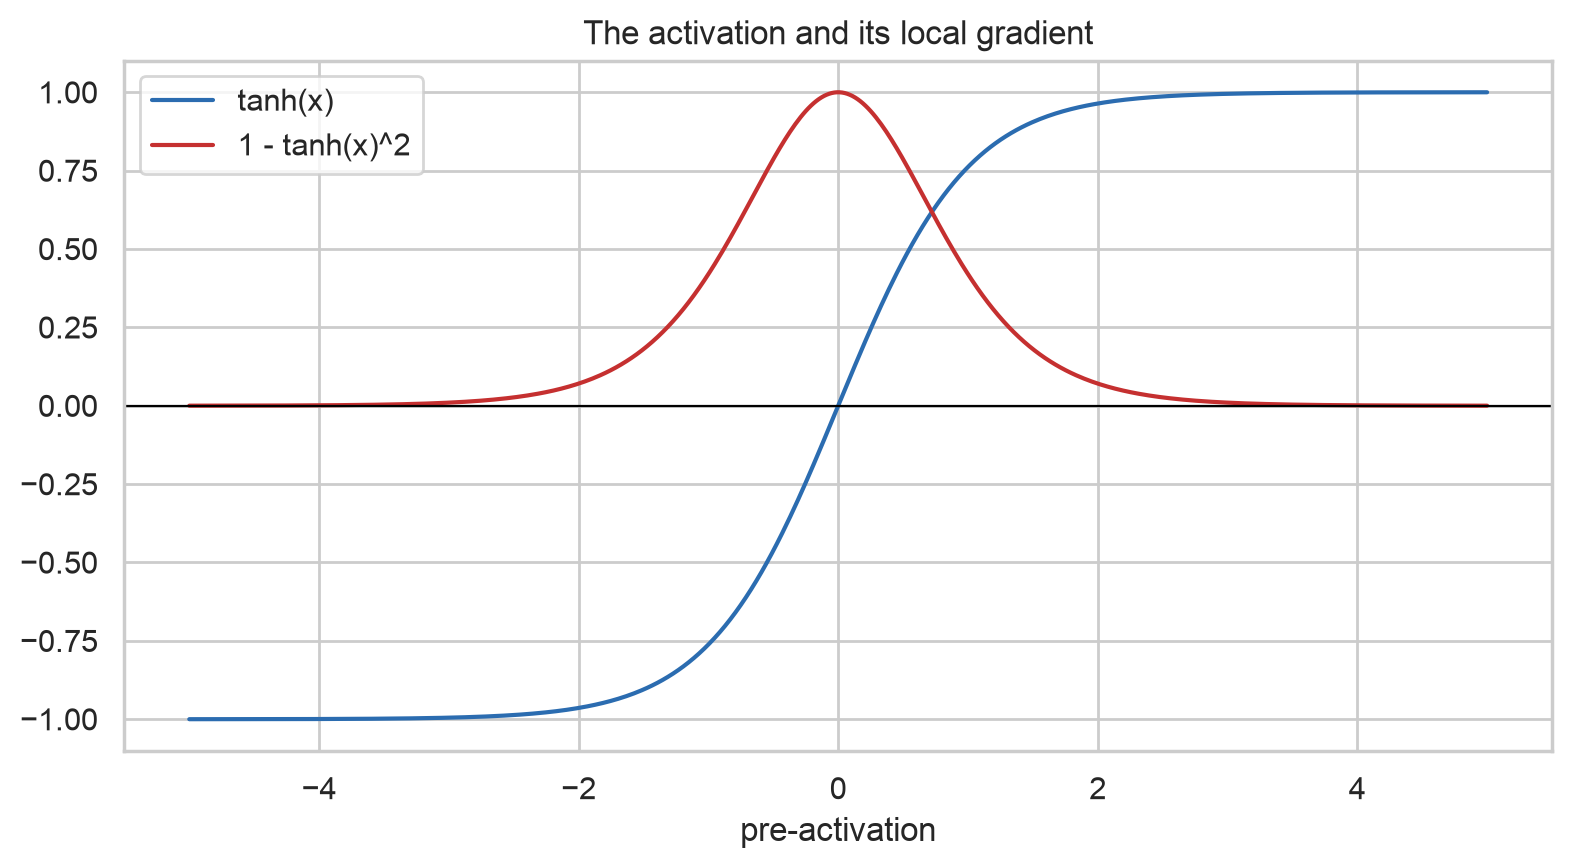

In [6]:
x = torch.linspace(-5, 5, 500)
tanh_x = torch.tanh(x)
tanh_grad = 1 - tanh_x.square()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, tanh_x, label="tanh(x)", color="#2b6cb0")
ax.plot(x, tanh_grad, label="1 - tanh(x)^2", color="#c53030")
ax.axhline(0, color="black", linewidth=0.8)
ax.set(xlabel="pre-activation", title="The activation and its local gradient")
ax.legend()
plt.tight_layout()
plt.show()

The practical diagnostic is not “does the activation exist?” but “where do its values live?” A histogram concentrated near -1 and +1 indicates saturation. A histogram concentrated near zero may indicate that the weights are too small. The useful region depends on the nonlinearity, but the principle is general: inspect the forward activations and the backward gradients together.

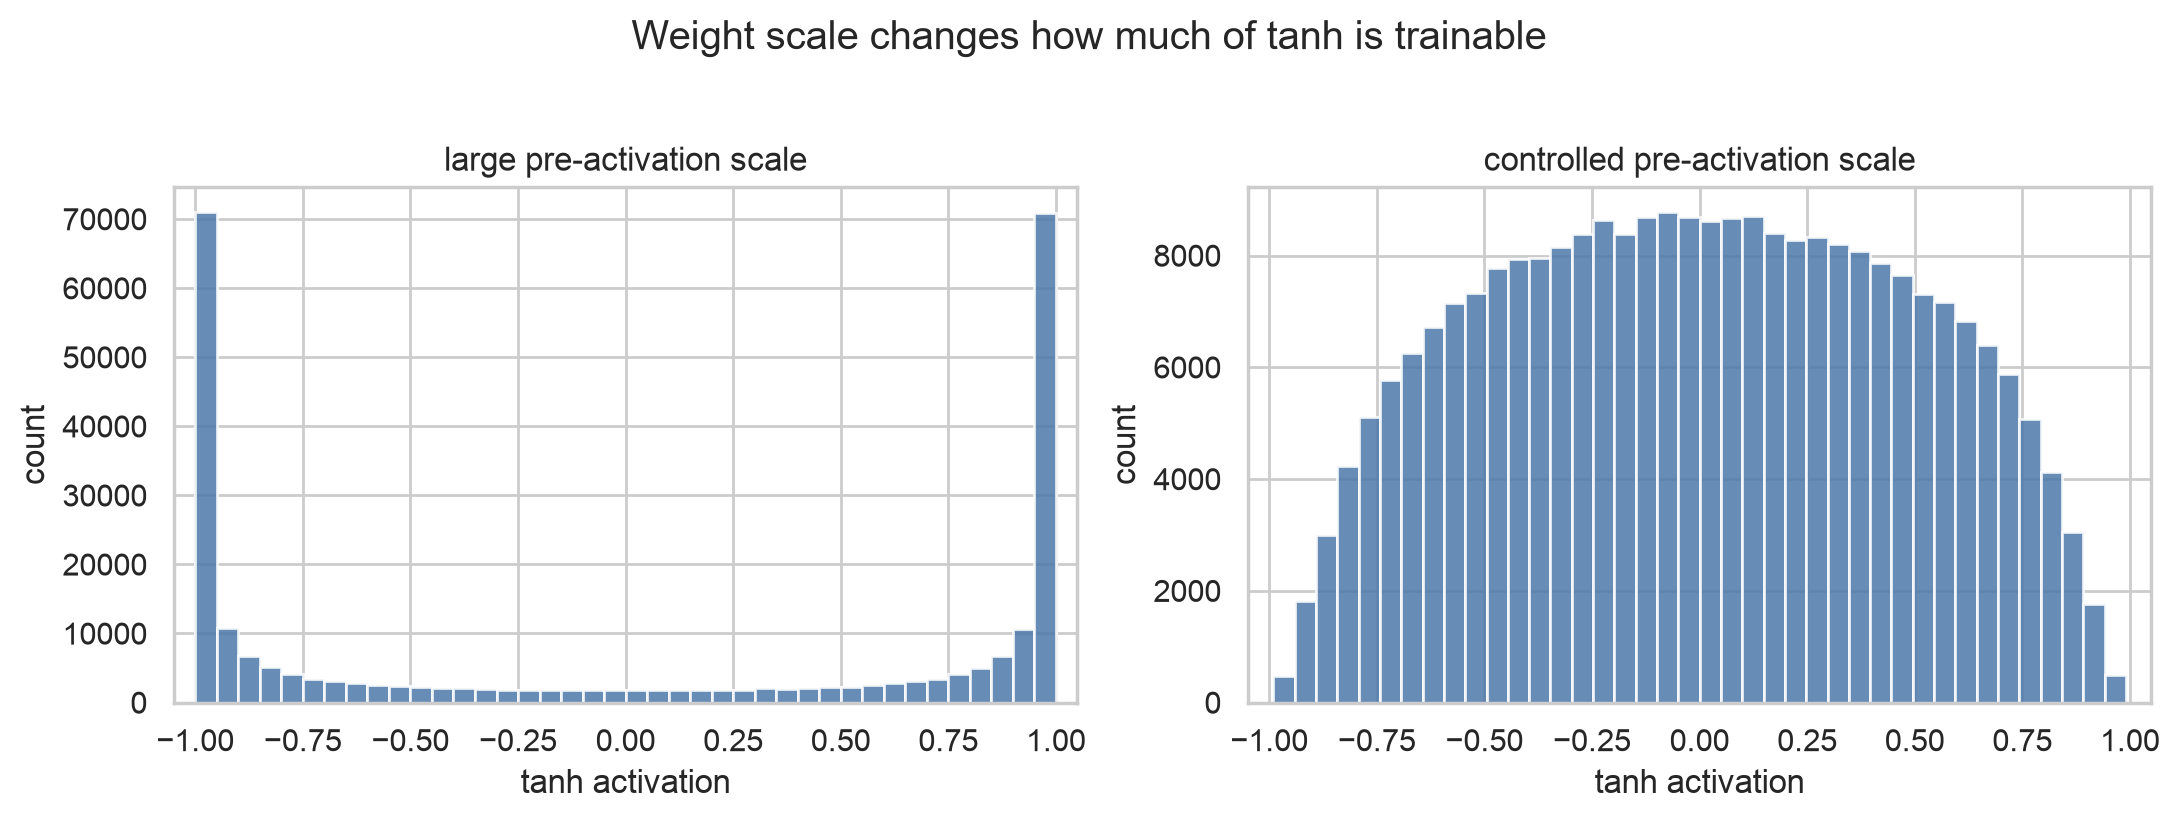

In [7]:
torch.manual_seed(11)
pre_activation_large = torch.randn(2048, 128) * 3.0
pre_activation_scaled = torch.randn(2048, 128) * 0.6
activations = {
    "large pre-activation scale": torch.tanh(pre_activation_large),
    "controlled pre-activation scale": torch.tanh(pre_activation_scaled),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (label, values) in zip(axes, activations.items()):
    ax.hist(values.flatten().tolist(), bins=40, color="#4c78a8", alpha=0.85)
    ax.set(title=label, xlabel="tanh activation", ylabel="count", xlim=(-1.05, 1.05))
plt.suptitle("Weight scale changes how much of tanh is trainable", y=1.02)
plt.tight_layout()
plt.show()

## 4. Dead ReLU units

`ReLU(x)=max(0,x)` has a derivative of zero whenever \(x<0\). If a unit is negative for every example, it produces zero for every example and receives zero gradient for every example. That unit is **dead**: its weights cannot recover through ordinary gradient descent.

A high learning rate can also push a previously useful ReLU unit entirely into the negative region. The heatmap below marks whether each unit is active for each example. A completely dark column is a dead unit.

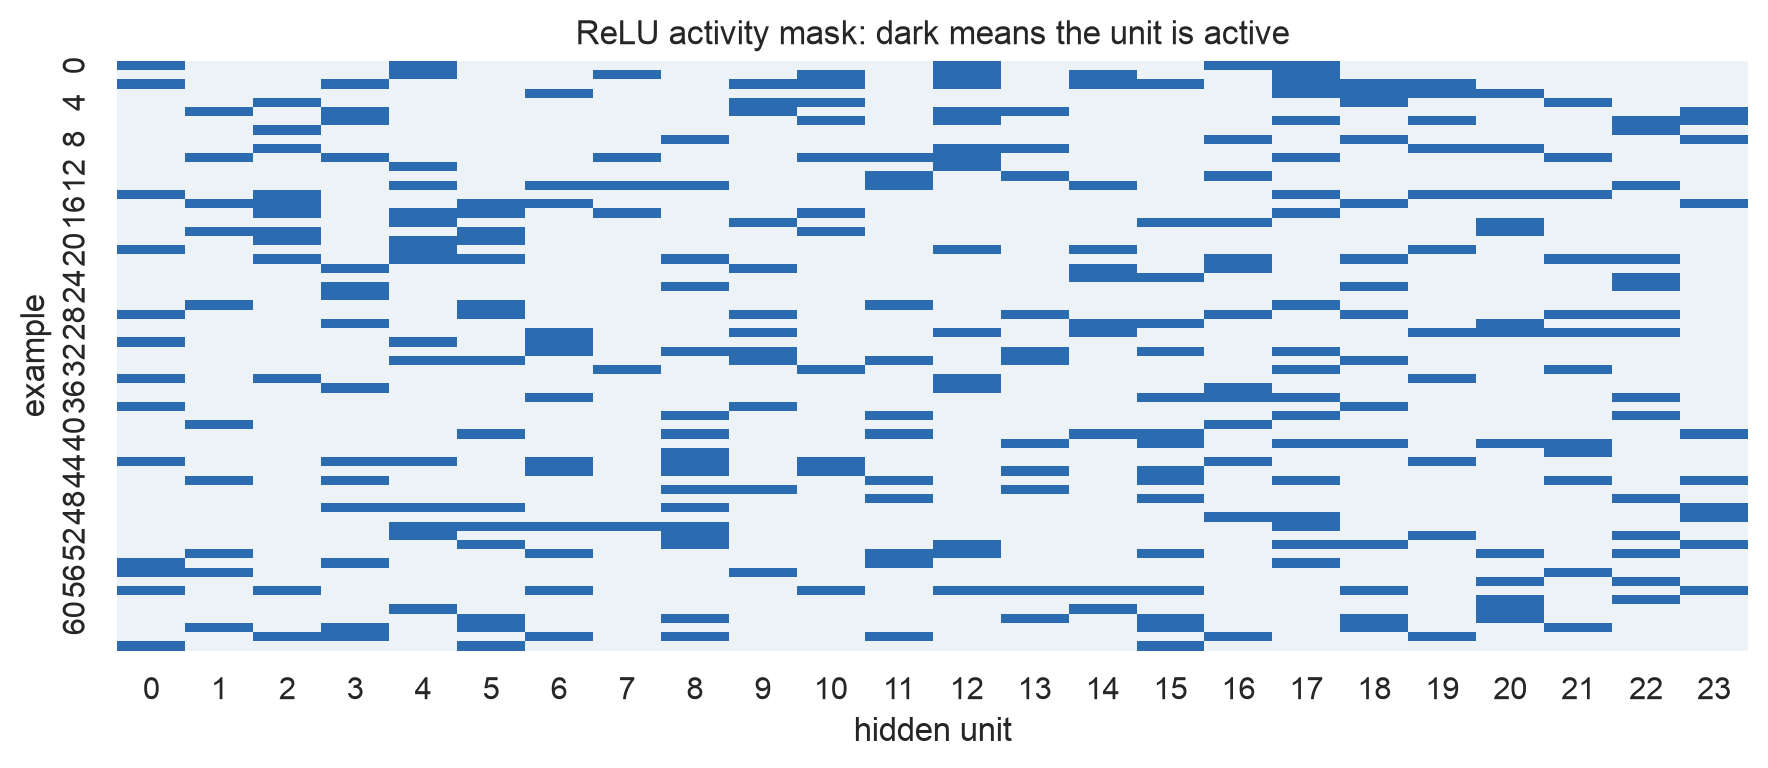

,hidden unit,active examples,dead
0,0,13,False
1,1,10,False
2,2,12,False
3,3,15,False
4,4,16,False
5,5,15,False
6,6,13,False
7,7,6,False
8,8,17,False
9,9,12,False


In [8]:
torch.manual_seed(5)
pre_relu = torch.randn(64, 24) - 0.8
active = (pre_relu > 0).float()

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(active, cmap=["#edf2f7", "#2b6cb0"], cbar=False, ax=ax)
ax.set(xlabel="hidden unit", ylabel="example", title="ReLU activity mask: dark means the unit is active")
plt.tight_layout()
plt.show()

active_counts = active.sum(dim=0)
pd.DataFrame({"hidden unit": torch.arange(active.shape[1]), "active examples": active_counts.long(), "dead": active_counts.eq(0)})

## 5. Why fan-in appears in initialization

For a linear layer \(y=xW\), each output is a sum of `fan_in` products. If the inputs and weights have comparable variance, increasing the number of summed terms increases the output variance. Without compensation, activations can grow as layers are stacked.

A basic variance-preserving rule therefore scales weights roughly by

\[
rac{1}{\sqrt{	ext{fan-in}}}.
\]

The exact constant depends on the activation and the initialization scheme. The useful idea is that initialization is chosen to keep signals in a workable range, rather than chosen independently of layer width.

In [9]:
torch.manual_seed(13)
fan_ins = torch.tensor([4, 16, 64, 256])
raw_std = []
scaled_std = []
for fan_in in fan_ins:
    inputs = torch.randn(4000, fan_in)
    raw_weights = torch.randn(fan_in, 32)
    scaled_weights = raw_weights / torch.sqrt(fan_in.float())
    raw_std.append((inputs @ raw_weights).std().item())
    scaled_std.append((inputs @ scaled_weights).std().item())

variance_table = pd.DataFrame({"fan-in": fan_ins, "unscaled output std": raw_std, "1/sqrt(fan-in) output std": scaled_std})
variance_table

,fan-in,unscaled output std,1/sqrt(fan-in) output std
0,4,2.148066,1.074033
1,16,3.917727,0.979432
2,64,8.080057,1.010007
3,256,16.078362,1.004898


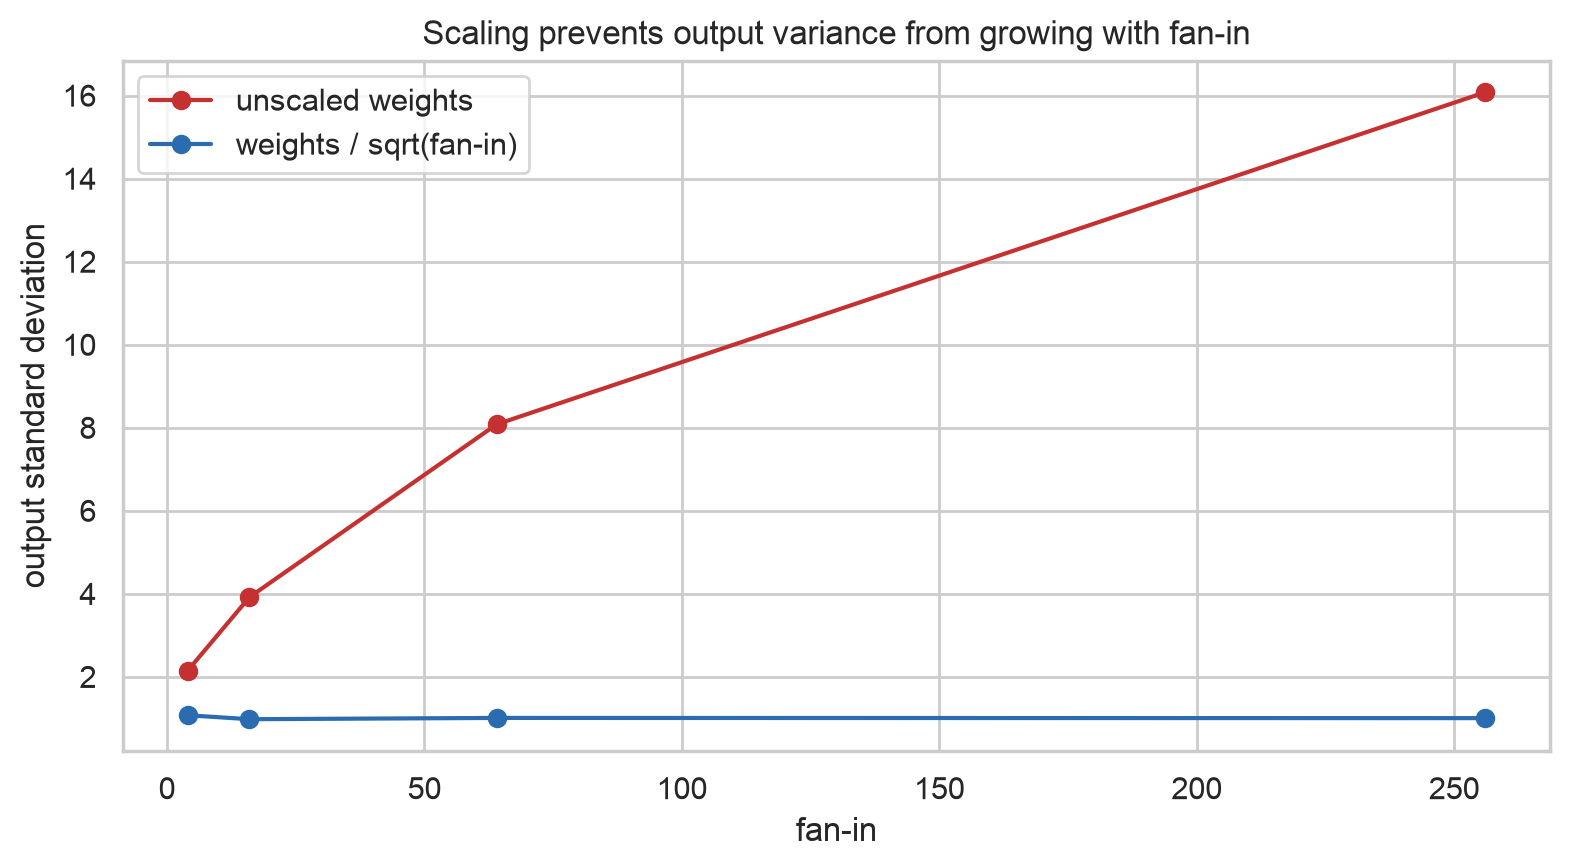

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(fan_ins, raw_std, marker="o", label="unscaled weights", color="#c53030")
ax.plot(fan_ins, scaled_std, marker="o", label="weights / sqrt(fan-in)", color="#2b6cb0")
ax.set(xlabel="fan-in", ylabel="output standard deviation", title="Scaling prevents output variance from growing with fan-in")
ax.legend()
plt.tight_layout()
plt.show()

## 6. BatchNorm: control the distribution, then learn the useful scale

Batch normalization standardizes each hidden unit over the current training batch:

\[
\hat h = rac{h-\mu_B}{\sqrt{\sigma_B^2+\epsilon}},\qquad y=\gamma\hat h+eta.
\]

The standardization keeps the activation distribution in a predictable range. The learned `gamma` and `beta` mean that the layer is not forced to remain unit Gaussian forever; it can recover a scale and offset that help the task.

There are two different kinds of state:

- `gamma` and `beta` are trainable parameters updated by backpropagation;
- running mean and variance are buffers updated during training and used at inference.

During training, examples in the same batch are coupled because they share \(\mu_B\) and \(\sigma_B\). During inference, a single example cannot define a reliable batch statistic, so the layer uses the running estimates.

In [11]:
torch.manual_seed(17)
raw = torch.randn(32, 8) * 2.5 + 4.0
mean = raw.mean(dim=0, keepdim=True)
std = raw.std(dim=0, keepdim=True, unbiased=False)
normalized = (raw - mean) / torch.sqrt(std.square() + 1e-5)

rows = []
for name, values in [("before", raw), ("after standardization", normalized)]:
    rows.append({"state": name, "mean across batch": values.mean().item(), "std across batch": values.std(unbiased=False).item()})
pd.DataFrame(rows)

,state,mean across batch,std across batch
0,before,4.144057e+00,2.318883
1,after standardization,1.722947e-08,0.999999


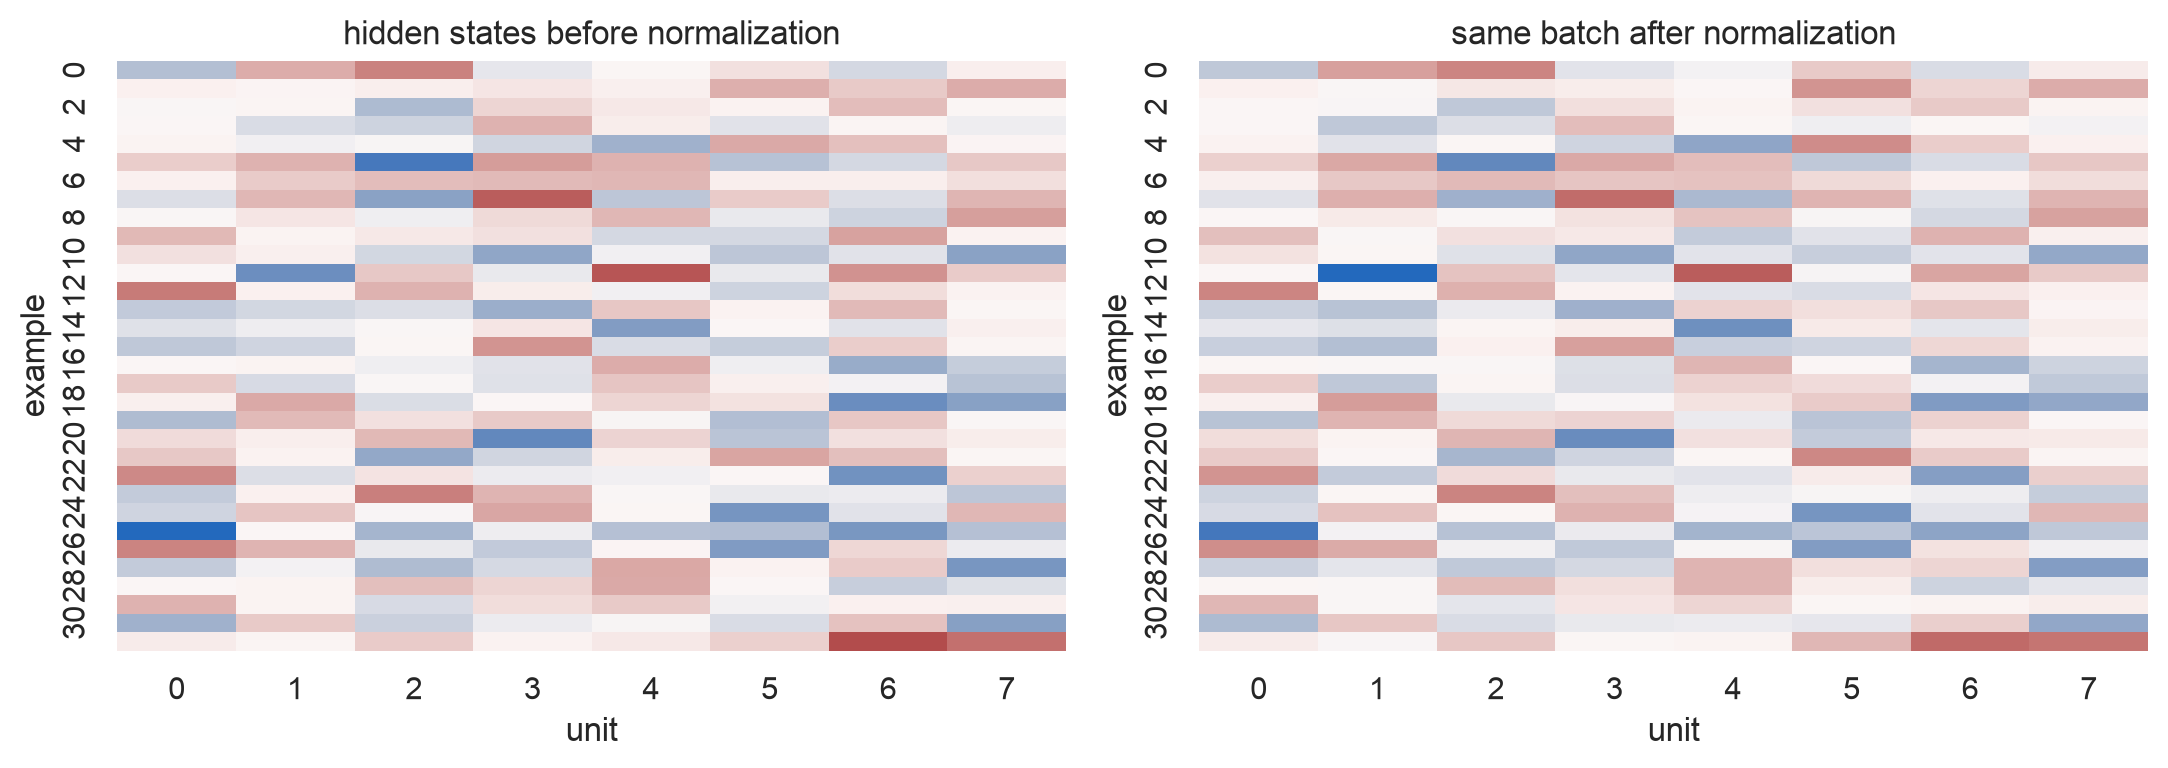

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(raw, cmap="vlag", center=raw.mean(), ax=axes[0], cbar=False)
axes[0].set(title="hidden states before normalization", xlabel="unit", ylabel="example")
sns.heatmap(normalized, cmap="vlag", center=0, ax=axes[1], cbar=False)
axes[1].set(title="same batch after normalization", xlabel="unit", ylabel="example")
plt.tight_layout()
plt.show()

## 7. Evaluation is part of the training design

Part 3 separates **train**, **development/validation**, and **test** data. The training split changes the parameters. The development split guides choices such as hidden width, learning rate, and initialization. The test split is held back for the final report.

Evaluation should not build a gradient graph. In PyTorch, `torch.no_grad()` makes that intent explicit and avoids unnecessary memory and bookkeeping. A lower training loss alone is not evidence that the model generalizes.

In [13]:
class TinyClassifier(nn.Module):
    def __init__(self, input_width=4, hidden_width=8, classes=3):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_width, hidden_width), nn.Tanh(), nn.Linear(hidden_width, classes))

    def forward(self, x):
        return self.net(x)

model = TinyClassifier()
inputs = torch.randn(12, 4)
targets = torch.randint(0, 3, (12,))

with torch.no_grad():
    validation_logits = model(inputs)
    validation_loss = nn.functional.cross_entropy(validation_logits, targets)

print(f"validation loss: {validation_loss.item():.3f}")
print(f"gradient graph attached: {validation_logits.requires_grad}")

validation loss: 1.081
gradient graph attached: False


## What Part 3 adds to the model-building story

A neural network is not only a forward formula. Its behavior depends on the distributions of the values and derivatives flowing through that formula.

- The output layer should begin near the loss expected from an uninformed model.
- Hidden pre-activations should avoid exploding and avoid living entirely in flat nonlinear regions.
- ReLU units must activate on at least some examples or they cannot learn.
- Weight scale should account for fan-in.
- Normalization can stabilize deep stacks, but BatchNorm couples examples during training and needs running statistics for inference.
- Train, development, and test measurements answer different questions.

These are diagnostics for understanding optimization. They do not replace held-out evaluation, and they do not guarantee that a model will learn a good language distribution.